# L12b: Predicting Thrombin Generation in Hemophilia A with Elman RNNs
In this lab, we use an Elman RNN to predict thrombin generation curves for patients with varying degrees of Factor VIII (FVIII) deficiency, the hallmark of [Hemophilia A](https://en.wikipedia.org/wiki/Haemophilia_A). We generate training data by simulating the [Hockin-Mann coagulation model](https://github.com/varnerlab/HockinMannModel.jl) at different FVIII levels, train an Elman RNN, and evaluate predictions across the clinical severity spectrum.

> __Learning Objectives:__
>
> By the end of this lab, you should be able to:
>
> * __Generate thrombin curves for Hemophilia A patients:__ Use the Hockin-Mann coagulation model with [`patient_initial_conditions(...)`](https://github.com/varnerlab/HockinMannModel.jl/blob/main/src/Simulate.jl) and [`percent_nominal_to_molar(...)`](https://github.com/varnerlab/HockinMannModel.jl/blob/main/src/Simulate.jl) to simulate thrombin generation at different Factor VIII levels.
> * __Train an Elman RNN for conditional time series prediction:__ Implement teacher forcing training where the RNN receives the current thrombin value and the FVIII level as input and predicts the next time step.
> * __Evaluate clinical relevance of RNN predictions:__ Compare predicted and actual thrombin generation curves across Hemophilia A severity categories (severe, moderate, mild, and normal) and assess whether the RNN captures clinically meaningful differences.

Let's get started!
___

## Setup, Data, and Prerequisites
We set up the computational environment by including the `Include.jl` file, loading any needed resources, such as sample datasets, and setting up any required constants.

> The [`include(...)` command](https://docs.julialang.org/en/v1/base/base/#include) evaluates the contents of the input source file, `Include.jl`, in the notebook's global scope. The `Include.jl` file sets paths, loads required external packages, and includes local source files in `src/`. For additional information on functions and types used in this material, see the [Julia programming language documentation](https://docs.julialang.org/en/v1/).

In [1]:
include(joinpath(@__DIR__, "Include.jl")); # include the Include.jl file

  Activating project at `~/Desktop/julia_work/CHEME-5820-Instances/Spring-2026/CHEME-5820-Labs-Spring-2026/labs/week-12/L12b`


In addition to standard Julia libraries, this lab uses [the `VLDataScienceMachineLearningPackage.jl` package](https://github.com/varnerlab/VLDataScienceMachineLearningPackage.jl) and [the `HockinMannModel.jl` package](https://github.com/varnerlab/HockinMannModel.jl). The `HockinMannModel.jl` package provides ODE-based simulations of the tissue factor-initiated coagulation cascade. It includes [the `patient_initial_conditions(...)` function](https://github.com/varnerlab/HockinMannModel.jl/blob/main/src/Simulate.jl) for setting custom factor levels and [the `percent_nominal_to_molar(...)` function](https://github.com/varnerlab/HockinMannModel.jl/blob/main/src/Simulate.jl) for converting clinical percentages to molar concentrations.

### Implementations
We use helper functions defined in the `src/` directory:

| Function | Source | Description |
| --- | --- | --- |
| [`generate_hemophilia_dataset(...)`](src/Simulation.jl) | `src/Simulation.jl` | Simulate the Hockin-Mann model at multiple FVIII levels and return thrombin curves (nM) |
| [`normalize_minmax(...)`](src/Simulation.jl) | `src/Simulation.jl` | Min-max normalize a data matrix to $[0,1]$ |
| [`normalize_minmax_percurve(...)`](src/Simulation.jl) | `src/Simulation.jl` | Min-max normalize each column of a data matrix independently to $[0,1]$ |
| [`denormalize_minmax(...)`](src/Simulation.jl) | `src/Simulation.jl` | Reverse min-max normalization to recover original scale |
| [`build_elman_rnn(...)`](src/ElmanRNN.jl) | `src/ElmanRNN.jl` | Initialize an Elman RNN with Xavier-scaled weights |
| [`forward_step(...)`](src/ElmanRNN.jl) | `src/ElmanRNN.jl` | Compute one time step of the Elman RNN |
| [`forward_sequence(...)`](src/ElmanRNN.jl) | `src/ElmanRNN.jl` | Run the RNN over a full sequence with teacher forcing |
| [`predict_sequence(...)`](src/ElmanRNN.jl) | `src/ElmanRNN.jl` | Generate a predicted sequence via autoregressive rollout |
| [`count_parameters(...)`](src/ElmanRNN.jl) | `src/ElmanRNN.jl` | Count total trainable parameters |

### Background: Hemophilia A and Coagulation

> __Hemophilia A__ is a bleeding disorder caused by deficiency of coagulation Factor VIII (FVIII). FVIII is a cofactor for Factor IXa in the intrinsic tenase complex, which activates Factor X. Reduced FVIII levels impair thrombin generation, leading to prolonged bleeding. Clinical severity is classified by FVIII activity level:
>
> * **Severe**: < 1% of normal FVIII activity
> * **Moderate**: 1% to 5% of normal
> * **Mild**: 5% to 40% of normal
> * **Normal**: > 40% of normal
>
> In this lab, we simulate thrombin generation curves at FVIII levels spanning 0.5% to 100% of normal to capture the full severity spectrum.

### Constants
We define simulation and training constants used throughout the lab. The simulation constants control the FVIII range and time resolution, while the RNN constants specify the network architecture and training hyperparameters.

In [2]:
# simulation constants -
number_of_curves = 50;          # total number of thrombin curves to generate
fviii_min = 0.5;                # minimum FVIII level: 0.5% of nominal (severe hemophilia)
fviii_max = 100.0;              # maximum FVIII level: 100% of nominal (normal)
TF_trigger = 5e-12;             # tissue factor trigger concentration: 5 pM (standard TGA)
saveat = 10.0;                  # save ODE solution every 10 seconds (121 time points)
tspan = (0.0, 1200.0);         # simulation time span: 0 to 1200 seconds (20 minutes)

# RNN architecture constants -
d_in = 2;                       # input dimension: [x_t, FVIII_normalized]
h_dim = 64;                     # hidden state dimension
d_out = 1;                      # output dimension: predicted x_{t+1}

# training constants -
num_epochs = 500;               # number of training epochs
learning_rate = 1e-3;           # Adam optimizer learning rate
train_fraction = 0.8;           # fraction of curves used for training (80% train, 20% test)
grad_clip = 1.0;                # gradient clipping threshold (max gradient norm)

___

## Task 1: Generate Thrombin Generation Data for Hemophilia A
We use the Hockin-Mann 2002 coagulation model to generate thrombin generation curves at different Factor VIII levels. [The `generate_hemophilia_dataset(...)` function](src/Simulation.jl) calls [the `patient_initial_conditions(...)` function](https://github.com/varnerlab/HockinMannModel.jl/blob/main/src/Simulate.jl) and [the `percent_nominal_to_molar(...)` function](https://github.com/varnerlab/HockinMannModel.jl/blob/main/src/Simulate.jl) from the `HockinMannModel.jl` package to set up each simulation.

> __Factor VIII titration__
>
> Reducing FVIII impairs the intrinsic tenase complex (FIXa:FVIIIa), which is responsible for amplifying Factor X activation during the propagation phase of coagulation. Lower FVIII levels produce smaller and delayed thrombin peaks. At severe deficiency (< 1%), thrombin generation is minimal.

Generate 50 thrombin curves at FVIII levels log-spaced from 0.5% to 100% of nominal using [the `range(...)` function](https://docs.julialang.org/en/v1/base/math/#Base.range), then visualize the results. The simulation results should be stored in the `time_vector::Vector{Float64}` variable (time points in seconds), the `thrombin_matrix::Matrix{Float64}` variable (rows are time points, columns are different FVIII levels, values in nM), and the `fviii_values::Vector{Float64}` variable (FVIII levels in percent nominal).

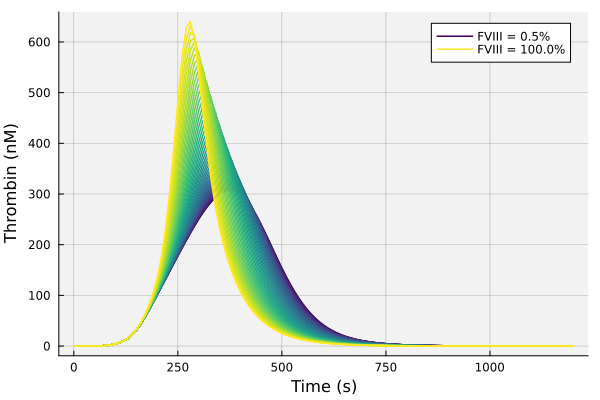

In [3]:
time_vector, thrombin_matrix, fviii_values = let

    # generate FVIII levels log-spaced from fviii_min to fviii_max -
    fviii_values = 10 .^ range(log10(fviii_min), log10(fviii_max), length=number_of_curves);

    # simulate thrombin generation at each FVIII level -
    time_vector, thrombin_matrix, fviii_values = generate_hemophilia_dataset(fviii_values; 
        TF=TF_trigger, tspan=tspan, saveat=saveat);

    # plot all thrombin curves colored by FVIII level -
    colors = palette(:viridis, number_of_curves);
    p = plot(xlabel="Time (s)", ylabel="Thrombin (nM)", legend=:topright,
        background_color_inside = :gray95, grid = true, gridalpha = 0.3);
    for j in 1:number_of_curves
        if j == 1
            plot!(p, time_vector, thrombin_matrix[:, j], color=colors[j], lw=1.5,
                label="FVIII = $(round(fviii_values[j], digits=1))%")
        elseif j == number_of_curves
            plot!(p, time_vector, thrombin_matrix[:, j], color=colors[j], lw=1.5,
                label="FVIII = $(round(fviii_values[j], digits=1))%")
        else
            plot!(p, time_vector, thrombin_matrix[:, j], color=colors[j], lw=1.5, label="")
        end
    end
    display(p)

    # return -
    (time_vector, thrombin_matrix, fviii_values)
end;

The curves should show that higher FVIII levels produce larger and earlier thrombin peaks, while severe deficiency results in minimal thrombin generation.

Next, we normalize the thrombin matrix globally to $[0,1]$ using [the `normalize_minmax(...)` function](src/Simulation.jl) and split into training and test sets using [the `randperm(...)` function](https://docs.julialang.org/en/v1/stdlib/Random/#Random.randperm). Global normalization preserves the amplitude differences between FVIII levels, so the RNN sees that severe cases produce near-zero thrombin while normal cases reach the full peak. This gives the model a direct signal about the FVIII effect on thrombin generation.

The normalized thrombin curves are stored in `X_norm::Matrix{Float64}` with values in $[0,1]$, the global normalization bounds in `thrombin_min::Float64` and `thrombin_max::Float64`, the normalized FVIII values in `fviii_norm::Vector{Float64}`, and the training and test indices in `train_idx::Vector{Int}` and `test_idx::Vector{Int}`.

In [4]:
X_norm, thrombin_min, thrombin_max, fviii_norm, fviii_norm_min, fviii_norm_max, train_idx, test_idx = let

    # normalize the thrombin matrix globally to [0, 1] -
    # global normalization preserves amplitude differences between FVIII levels:
    # severe cases stay near 0, normal cases reach 1.0. This gives the RNN
    # a direct signal about the FVIII effect on thrombin generation -
    X_norm, thrombin_min, thrombin_max = normalize_minmax(thrombin_matrix);

    # normalize FVIII values to [0, 1] using log-transform then min-max scaling -
    # log-transform because FVIII spans orders of magnitude (0.5% to 100%) -
    fviii_log = log10.(fviii_values);
    fviii_norm_min = minimum(fviii_log);
    fviii_norm_max = maximum(fviii_log);
    fviii_norm = (fviii_log .- fviii_norm_min) ./ (fviii_norm_max - fviii_norm_min);

    # shuffle curve indices and split into train/test sets -
    Random.seed!(42); # set seed for reproducibility
    perm = randperm(number_of_curves); # random permutation of curve indices
    n_train = Int(round(train_fraction * number_of_curves)); # number of training curves
    train_idx = perm[1:n_train];           # first 80% for training
    test_idx = perm[(n_train+1):end];      # remaining 20% for testing

    # print dataset summary -
    println("Dataset: $(number_of_curves) curves, $(size(X_norm, 1)) time points each");
    println("Training: $(length(train_idx)) curves, Test: $(length(test_idx)) curves");
    println("Global thrombin range (nM): min=$(round(thrombin_min, digits=2)), max=$(round(thrombin_max, digits=2))");

    # return all outputs -
    (X_norm, thrombin_min, thrombin_max, fviii_norm, fviii_norm_min, fviii_norm_max, train_idx, test_idx)
end;

Dataset: 50 curves, 121 time points each
Training: 40 curves, Test: 10 curves
Global thrombin range (nM): min=0.0, max=640.25


### Things to think about
* __Why log-space the FVIII levels?__ The clinical severity categories span orders of magnitude (0.5% to 100%). Log-spacing ensures we have adequate representation of severe and moderate cases, not just mild and normal.
* __Why use global normalization instead of per-curve normalization?__ Global normalization preserves the amplitude differences between FVIII levels. The RNN sees that severe cases produce near-zero thrombin while normal cases reach the full peak, giving it a direct signal about the FVIII effect. Per-curve normalization would map every peak to 1.0, hiding the amplitude information from the model.

___

## Task 2: Build and Train the Elman RNN
We construct and train an Elman RNN for autoregressive thrombin curve prediction. At each time step, the RNN receives the input $\mathbf{x}_t = [x_t, c]^\top$ where $x_t$ is the normalized thrombin value and $c$ is the normalized FVIII level, and predicts $\hat{x}_{t+1}$.

> __Elman RNN equations (from L12a lecture)__
>
> $$
\begin{align*}
\mathbf{h}_t &= \tanh(\mathbf{U}_h \mathbf{h}_{t-1} + \mathbf{W}_x \mathbf{x}_t + \mathbf{b}_h) \\
\mathbf{y}_t &= \sigma(\mathbf{W}_y \mathbf{h}_t + \mathbf{b}_y)
\end{align*}
> $$
> For autoregressive time series prediction, we set $\mathbf{x}_t = [x_t, c]^\top \in \mathbb{R}^{2}$ where $x_t$ is the normalized thrombin value at time $t$ and $c$ is the normalized FVIII level. The output $y_t \in \mathbb{R}$ is the predicted value $\hat{x}_{t+1}$. The output uses a sigmoid activation because targets are normalized to $[0,1]$. A linear output layer is unbounded: during teacher forcing the model never sees its own out-of-range predictions, so small errors compound immediately during autoregressive rollout.
>
> The model is trained with teacher forcing: at each step, the true previous value is provided as input. The loss is mean squared error between predictions and targets. We use [the `Flux.withgradient(...)` function](https://fluxml.ai/Flux.jl/stable/training/training/#Flux.withgradient-Tuple{Any,%20Vararg{Any}}) for gradient computation and [the `Adam` optimizer](https://fluxml.ai/Flux.jl/stable/training/optimisers/#Flux.Optimise.Adam) for parameter updates.

We use [the `build_elman_rnn(...)` function](src/ElmanRNN.jl) to initialize the model. The model is stored in the `model::MyElmanRNNModel` variable.

In [5]:
model = let

    # build the Elman RNN with d_in=2, h=64, d_out=1 -
    model = build_elman_rnn(d_in, h_dim, d_out; seed=42);
    println("Elman RNN: d_in=$(d_in), h=$(h_dim), d_out=$(d_out)");
    println("Total parameters: $(count_parameters(model))");

    # return initialized model -
    model
end;

Elman RNN: d_in=2, h=64, d_out=1
Total parameters: 4353


Now, train the model. Use [`OptimiserChain`](https://fluxml.ai/Optimisers.jl/dev/api/#Optimisers.OptimiserChain) to combine [`ClipGrad`](https://fluxml.ai/Optimisers.jl/dev/api/#Optimisers.ClipGrad) with [`Adam`](https://fluxml.ai/Flux.jl/stable/training/optimisers/#Flux.Optimise.Adam) for gradient clipping. The per-epoch average MSE loss values should be stored in the `loss_history::Vector{Float64}` variable. Use [the `forward_sequence(...)` function](src/ElmanRNN.jl) for the teacher forcing forward pass and [the `Flux.update!(...)` function](https://fluxml.ai/Flux.jl/stable/training/training/#Flux.update!) to apply gradient updates. The training loop should save a checkpoint at every new best loss using [`JLD2.jldsave(...)`](https://juliaio.github.io/JLD2.jl/dev/) so you do not have to re-train from scratch each time you run the notebook.

In [6]:
loss_history = let

    # check for a pre-trained model checkpoint -
    checkpoint_path = joinpath(@__DIR__, "data", "elman_best_model.jld2");
    if isfile(checkpoint_path)
        println("Loading pre-trained model from $(checkpoint_path)");
        checkpoint = JLD2.load(checkpoint_path);
        Flux.loadmodel!(model, checkpoint["model_state"]);
        history = checkpoint["loss_history"];
        println("Loaded model with $(length(history)) epochs, best loss = $(round(minimum(history), sigdigits=4))");
    else

        # initialize the optimizer with gradient clipping -
        opt_state = Flux.setup(OptimiserChain(ClipGrad(grad_clip), Adam(learning_rate)), model);
        history = Vector{Float64}();   # stores average loss per epoch
        T = size(X_norm, 1);           # number of time points per curve
        best_loss = Inf;               # track best loss for checkpointing

        # training loop -
        for epoch in 1:num_epochs
            epoch_loss = 0.0;

            # iterate over training curves -
            for idx in train_idx

                # prepare data for this curve -
                curve = reshape(X_norm[:, idx], :, 1);  # T x 1 matrix
                condition = fviii_norm[idx];              # normalized FVIII level
                targets = curve[2:end, 1];               # true x_{t+1} values

                # compute loss and gradients using teacher forcing -
                loss_val, grads = Flux.withgradient(model) do m
                    preds, _ = forward_sequence(m, curve, condition);
                    sum((preds[:, 1] .- targets) .^ 2) / (T - 1)
                end

                # apply gradient update -
                Flux.update!(opt_state, model, grads[1]);
                epoch_loss += loss_val;
            end

            # record average loss for this epoch -
            avg_loss = epoch_loss / length(train_idx);
            push!(history, avg_loss);

            # save model checkpoint at new best loss -
            if avg_loss < best_loss
                best_loss = avg_loss;
                JLD2.jldsave(checkpoint_path;
                    model_state = Flux.state(model),
                    loss_history = history
                );
            end

            # print progress every 100 epochs -
            if epoch % 100 == 0 || epoch == 1
                println("Epoch $(epoch)/$(num_epochs): loss = $(round(avg_loss, sigdigits=4)), best = $(round(best_loss, sigdigits=4))");
            end
        end
    end

    # return the loss history -
    history
end;

Loading pre-trained model from /Users/jdv27/Desktop/julia_work/CHEME-5820-Instances/Spring-2026/CHEME-5820-Labs-Spring-2026/labs/week-12/L12b/data/elman_best_model.jld2
Loaded model with 472 epochs, best loss = 3.173e-6


Let's plot the training loss to verify convergence.

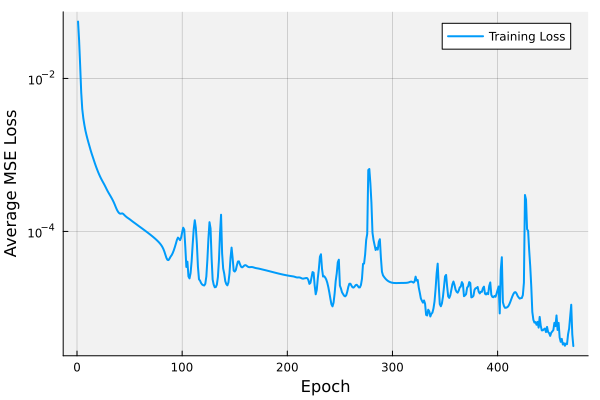

In [7]:
let
    # plot loss history on log scale to visualize convergence -
    plot(1:length(loss_history), loss_history, xlabel="Epoch", ylabel="Average MSE Loss",
        label="Training Loss", lw=2, yscale=:log10,
        background_color_inside = :gray95, grid = true, gridalpha = 0.3)
end

### Things to think about
* __What role does teacher forcing play in training stability?__ Consider what would happen if the model's own predictions were used as input during training instead of the true values.
* __How does the hidden state $\mathbf{h}_t$ encode information about the curve trajectory?__ The hidden state must capture both the current position on the curve and the rate of change.

___

## Task 3: Evaluate Predictions Across the Clinical Spectrum
We evaluate the trained RNN on held-out FVIII levels using autoregressive rollout and interpret the results across the clinical severity spectrum of Hemophilia A. [The `predict_sequence(...)` function](src/ElmanRNN.jl) starts from the true initial value $x_0$ and feeds the model's own predictions back as input at each subsequent step. We use [the `denormalize_minmax(...)` function](src/Simulation.jl) to convert predictions back to nM.

> __Autoregressive evaluation and clinical significance__
>
> During autoregressive rollout, prediction errors can compound over time. This is the true test of whether the RNN has learned the dynamics of thrombin generation. Thrombin generation assays (TGA) are used to evaluate a patient's overall coagulation capacity. The peak thrombin concentration and time-to-peak are key indicators: severe hemophilia patients produce minimal thrombin, while mild and normal patients show progressively stronger responses. Accurate prediction of these curves could support treatment planning and dose optimization for factor replacement therapy.

We select one representative FVIII level from each severity category and compare the RNN predictions side-by-side. We find the nearest curve to each target FVIII level using [the `argmin(...)` function](https://docs.julialang.org/en/v1/base/collections/#Base.argmin).

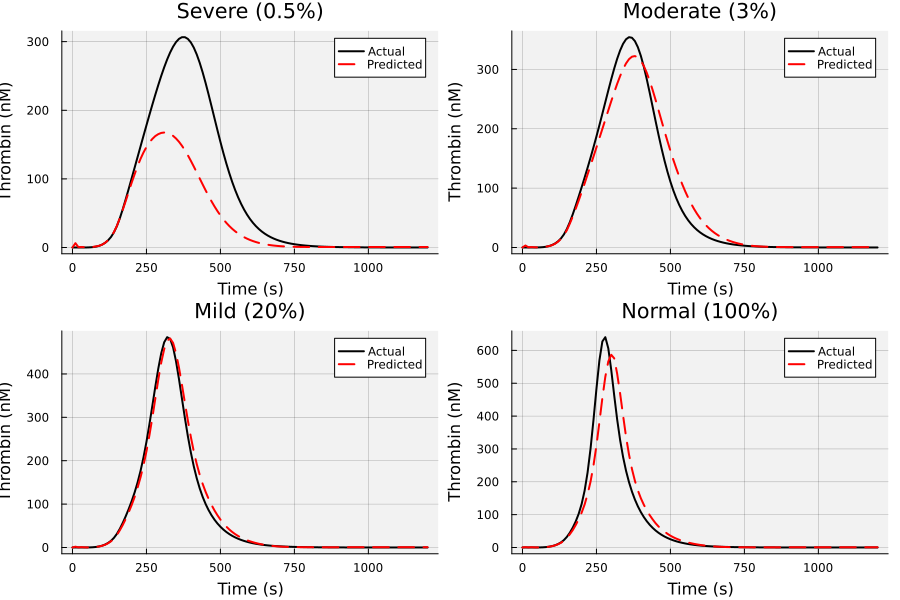

In [8]:
let

    # define representative FVIII levels for each clinical severity category -
    target_levels = [0.5, 3.0, 20.0, 100.0];              # percent nominal
    severity_labels = ["Severe (0.5%)", "Moderate (3%)",   # display labels
                       "Mild (20%)", "Normal (100%)"];
    T = size(X_norm, 1); # number of time points

    # generate predictions for each severity category -
    plots_array = [];
    for (k, target) in enumerate(target_levels)

        # find the curve closest to this target FVIII level -
        idx = argmin(abs.(fviii_values .- target));

        # autoregressive prediction: start from true x_0 and roll forward -
        x_0 = X_norm[1, idx];              # initial normalized thrombin value
        condition = fviii_norm[idx];        # normalized FVIII level for this curve
        pred_norm = predict_sequence(model, x_0, condition, T); # generate T predicted steps

        # convert predictions back to nM using global normalization bounds -
        pred_nM = denormalize_minmax(pred_norm, thrombin_min, thrombin_max);
        actual_nM = thrombin_matrix[:, idx]; # ground truth curve in nM

        # plot actual vs predicted for this severity category -
        p = plot(time_vector, actual_nM, label="Actual", lw=2, color=:black,
            background_color_inside = :gray95, grid = true, gridalpha = 0.3);
        plot!(p, time_vector, pred_nM, label="Predicted", lw=2, color=:red, ls=:dash);
        plot!(p, xlabel="Time (s)", ylabel="Thrombin (nM)", title=severity_labels[k]);
        push!(plots_array, p);
    end

    # combine into a 2x2 grid -
    plot(plots_array..., layout=(2, 2), size=(900, 600))
end

Next, we build a comparison table of TGA features for all test curves. We compare actual and predicted peak thrombin and time-to-peak using [the `argmax(...)` function](https://docs.julialang.org/en/v1/base/collections/#Base.argmax) and compute MSE using [the `mean(...)` function](https://docs.julialang.org/en/v1/stdlib/Statistics/#Statistics.mean).

In [9]:
let

    # initialize -
    T = size(X_norm, 1); # number of time points
    rows = [];           # collect table rows as named tuples

    # iterate over test curves sorted by FVIII level -
    for idx in sort(test_idx, by=i -> fviii_values[i])

        # generate autoregressive prediction for this test curve -
        x_0 = X_norm[1, idx];              # initial normalized thrombin value
        condition = fviii_norm[idx];        # normalized FVIII level
        pred_norm = predict_sequence(model, x_0, condition, T);

        # convert predictions back to nM using global normalization bounds -
        pred_nM = denormalize_minmax(pred_norm, thrombin_min, thrombin_max);
        actual_nM = thrombin_matrix[:, idx]; # ground truth curve in nM

        # classify clinical severity based on FVIII percentage -
        fviii_pct = fviii_values[idx];
        severity = if fviii_pct < 1.0
            "Severe"    # < 1% of normal FVIII activity
        elseif fviii_pct < 5.0
            "Moderate"  # 1% to 5% of normal
        elseif fviii_pct < 40.0
            "Mild"      # 5% to 40% of normal
        else
            "Normal"    # > 40% of normal
        end;

        # compute TGA features: peak thrombin, time-to-peak -
        actual_peak = maximum(actual_nM);                # actual peak thrombin (nM)
        actual_tpeak = time_vector[argmax(actual_nM)];   # actual time-to-peak (s)
        pred_peak = maximum(pred_nM);                    # predicted peak thrombin (nM)
        pred_tpeak = time_vector[argmax(pred_nM)];       # predicted time-to-peak (s)

        # compute MSE on normalized scale to match training loss -
        actual_norm = X_norm[:, idx];
        mse = mean((pred_norm .- actual_norm) .^ 2);

        # add row to table -
        push!(rows, (
            FVIII_pct = round(fviii_pct, digits=1),
            Severity = severity,
            Actual_Peak_nM = round(actual_peak, digits=1),
            Pred_Peak_nM = round(pred_peak, digits=1),
            Actual_tpeak_s = round(actual_tpeak, digits=0),
            Pred_tpeak_s = round(pred_tpeak, digits=0),
            MSE = round(mse, sigdigits=4)
        ));
    end

    # display as a formatted table -
    df = DataFrame(rows);
    pretty_table(df; backend = :text,
        fit_table_in_display_horizontally = false,
        fit_table_in_display_vertically = false,
        table_format = TextTableFormat(borders = text_table_borders__compact))
end

 ----------- ---------- ---------------- -------------- ---------------- -------------- -----------
  FVIII_pct   Severity   Actual_Peak_nM   Pred_Peak_nM   Actual_tpeak_s   Pred_tpeak_s         MSE 
    Float64     String          Float64        Float64          Float64        Float64     Float64 
 ----------- ---------- ---------------- -------------- ---------------- -------------- -----------
        0.6     Severe            309.2          174.5            370.0          320.0    0.008369
        1.0     Severe            316.4          195.9            370.0          340.0    0.004828
        1.2   Moderate            321.2          212.4            370.0          360.0    0.003213
        2.0   Moderate            336.8          272.3            370.0          390.0    0.001656
        3.5   Moderate            359.7          333.3            360.0          370.0    0.000835
       12.8       Mild            446.3          446.8            330.0          340.0    0.000216
      

### Things to think about
* __Where does the model perform best and worst?__ Consider whether the RNN captures the dynamics better for normal, mild, moderate, or severe cases. Why might some regions of the FVIII spectrum be harder to predict?
* __How does autoregressive error accumulation affect predictions?__ Look at the later time points of the predicted curves. Do errors grow over time? How does this relate to the vanishing/exploding gradient problem discussed in the L12a lecture?
* __What are the limitations of this approach?__ Consider factors not captured by the Hockin-Mann model (platelet function, fibrinolysis, patient variability) and how they might affect real-world predictions. Would gated architectures (LSTMs, GRUs) better capture the slow rise and decay phases of the thrombin curve?

___

## Summary
In this lab, we simulated thrombin generation curves for Hemophilia A patients at varying Factor VIII levels, trained an Elman RNN to predict full thrombin time courses, and evaluated predictions across the clinical severity spectrum.

> __Key Takeaways:__
>
> * **Mechanistic ODE models provide training data for patient-specific predictions:** The Hockin-Mann coagulation model generates thrombin curves that vary systematically with Factor VIII levels, capturing the clinical spectrum from severe hemophilia to normal coagulation.
> * **Elman RNNs learn conditional time series dynamics from simulation data:** By conditioning on the FVIII level, the RNN learns to predict thrombin generation curves across the severity spectrum using a single trained model.
> * **Autoregressive rollout reveals model limitations for clinical applications:** Prediction errors compound during rollout, particularly for longer time horizons. This motivates advanced architectures (LSTMs, GRUs) that better handle long-range temporal dependencies.

For more on RNN architectures and the training challenges that motivate gating mechanisms, see the [L12a lecture on Recurrent Neural Networks](../../../CHEME-5820-Lectures-Spring-2026/lectures/week-12/L12a/CHEME-5820-L12a-Lecture-RecurrentNetworks-Spring-2026.ipynb).
___